# **Taller 07: Clasificación de dígitos escritos a mano: KNN y Vecinos por Radio (RNN)**
### Inteligencia Artificial ELP 8012 - Universidad del Norte - Profesor: Eduardo Zurek, PH.D. 
### **Grupo:** Natalia Carpintero, Paula Núñez e Isabella Arrieta.

En este cuaderno se diseñan e implementan dos clasificadores basados en vecindad para
reconocer dígitos manuscritos (0-9) del conjunto `digits` de scikit-learn:

1. **KNN (K-Nearest Neighbors)**: clasifica cada muestra según la clase mayoritaria
   entre sus **K** vecinos más cercanos.
2. **RNN (Radius Neighbors)**: clasifica cada muestra según la clase mayoritaria entre
   los vecinos que se encuentran a una distancia menor o igual a un **radio R**. Aquí
   **RNN significa "vecinos dentro de un radio", no red neuronal recurrente**.

Metodología general que se sigue en ambos casos:

* Partición del conjunto de datos en **80 % entrenamiento / 20 % prueba** (estratificada).
* Selección de hiperparámetro (K o R) mediante **validación cruzada con 4 particiones**
  (K-fold = 4) usando **solo el conjunto de entrenamiento**.
* Para cada valor del hiperparámetro se calculan varias métricas de desempeño y se
  grafican para observar su comportamiento.
* Se selecciona el valor con mejor desempeño y se entrena el modelo final con **todo**
  el conjunto de entrenamiento, evaluándolo **una sola vez** sobre el conjunto de
  prueba reservado.


## Carga y exploración del conjunto de datos `digits`

El conjunto `digits` de scikit-learn contiene 1797 imágenes de dígitos manuscritos de
8x8 píxeles (64 características por muestra), con valores de intensidad de gris entre
0 y 16. La variable objetivo es el dígito representado (0 a 9).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

digits = load_digits()
X, y = digits.data, digits.target

print(f"Forma de X (muestras, características): {X.shape}")
print(f"Clases presentes: {np.unique(y)}")
print(f"Muestras por clase:\n{np.bincount(y)}")


Forma de X (muestras, características): (1797, 64)
Clases presentes: [0 1 2 3 4 5 6 7 8 9]
Muestras por clase:
[178 182 177 183 181 182 181 179 174 180]


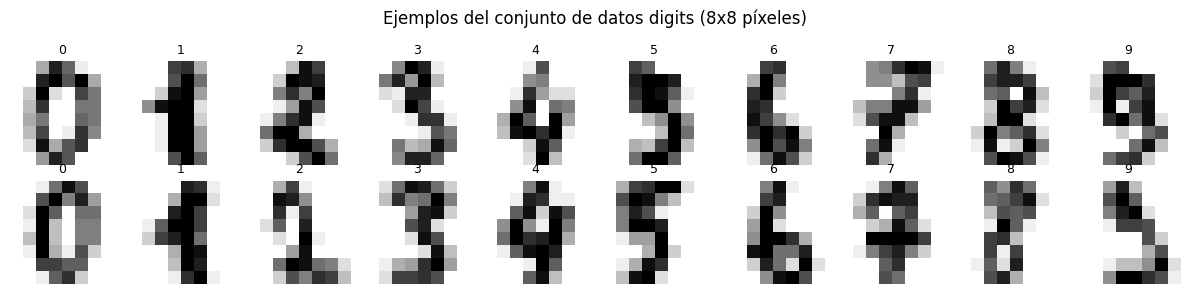

In [2]:
# Visualización de algunos ejemplos del conjunto de datos
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for clase in range(10):
    idx = np.where(y == clase)[0][0]
    ax = axes[0, clase] if clase < 10 else None
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(str(digits.target[i]), fontsize=9)
    ax.axis("off")
fig.suptitle("Ejemplos del conjunto de datos digits (8x8 píxeles)")
fig.tight_layout()
plt.show()


## Partición 80 % entrenamiento / 20 % prueba

La partición se hace de forma **estratificada** para conservar la proporción de cada
dígito en ambos subconjuntos. El conjunto de prueba se aparta desde ahora y **no se
vuelve a tocar** hasta la evaluación final de cada clasificador ya calibrado.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")


Entrenamiento: 1437 muestras
Prueba:        360 muestras


Las características son intensidades de píxel en escalas similares (0-16), pero
aun así se estandarizan (media 0, desviación 1) porque los clasificadores por vecindad
se basan en distancias euclidianas y son sensibles a la escala. El escalador se ajusta
**dentro de cada partición de validación cruzada** (y luego sobre todo el
entrenamiento para el modelo final) para evitar fuga de información desde los datos
de validación/prueba.

## Clasificador KNN: selección de K por validación cruzada (K-fold = 4)

Se define un rango de valores de **K** (número de vecinos) y, para cada uno, se
realiza una validación cruzada estratificada de **4 particiones** sobre el conjunto de
entrenamiento. En cada partición se ajusta un `StandardScaler` y un
`KNeighborsClassifier` (votos ponderados por distancia) y se calculan cuatro métricas
promediadas sobre las 4 particiones:

* **Accuracy** (exactitud global)
* **F1 macro** (promedio de F1 por clase, sin ponderar por tamaño de clase)
* **Precisión macro**
* **Sensibilidad (recall) macro**

Como el problema tiene 10 clases balanceadas, las versiones "macro" de las métricas
son las más informativas para comparar el desempeño en todos los dígitos por igual.


In [4]:
rango_K = list(range(1, 31))            # rango de valores de K a evaluar
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

metricas_knn = {
    "Accuracy": np.zeros((len(rango_K), cv.get_n_splits())),
    "F1 macro": np.zeros((len(rango_K), cv.get_n_splits())),
    "Precisión macro": np.zeros((len(rango_K), cv.get_n_splits())),
    "Recall macro": np.zeros((len(rango_K), cv.get_n_splits())),
}

for i, k in enumerate(rango_K):
    for j, (idx_tr, idx_val) in enumerate(cv.split(X_train, y_train)):
        X_tr, X_val = X_train[idx_tr], X_train[idx_val]
        y_tr, y_val = y_train[idx_tr], y_train[idx_val]

        escalador = StandardScaler().fit(X_tr)
        X_tr_s = escalador.transform(X_tr)
        X_val_s = escalador.transform(X_val)

        clf = KNeighborsClassifier(n_neighbors=k, weights="distance")
        clf.fit(X_tr_s, y_tr)
        pred = clf.predict(X_val_s)

        metricas_knn["Accuracy"][i, j] = accuracy_score(y_val, pred)
        metricas_knn["F1 macro"][i, j] = f1_score(y_val, pred, average="macro")
        metricas_knn["Precisión macro"][i, j] = precision_score(y_val, pred, average="macro")
        metricas_knn["Recall macro"][i, j] = recall_score(y_val, pred, average="macro")

promedio_knn = {nombre: valores.mean(axis=1) for nombre, valores in metricas_knn.items()}
desv_knn = {nombre: valores.std(axis=1) for nombre, valores in metricas_knn.items()}

print("Validación cruzada de KNN completada para K en "
      f"[{rango_K[0]}, {rango_K[-1]}].")


Validación cruzada de KNN completada para K en [1, 30].


### Figura: métricas de desempeño en función de K

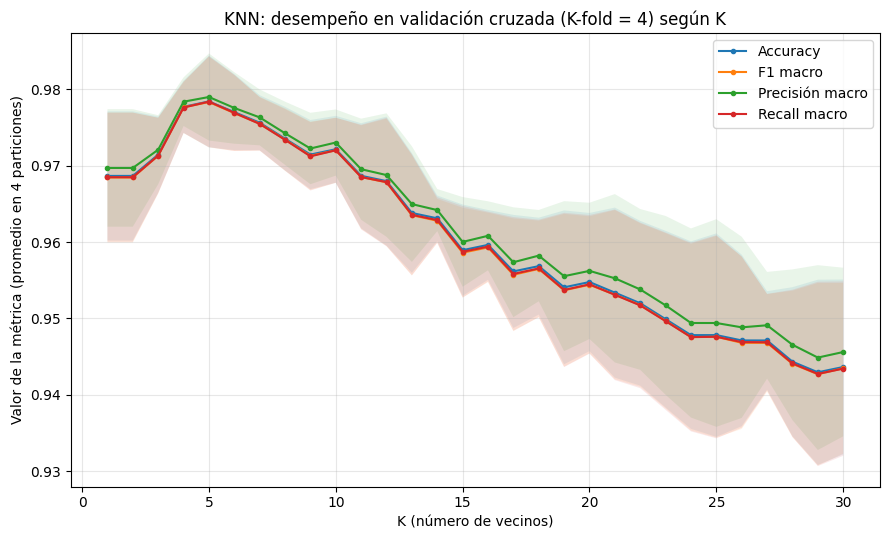

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for nombre, valores in promedio_knn.items():
    ax.plot(rango_K, valores, marker="o", markersize=3, label=nombre)
    ax.fill_between(rango_K, valores - desv_knn[nombre], valores + desv_knn[nombre], alpha=0.1)

ax.set_xlabel("K (número de vecinos)")
ax.set_ylabel("Valor de la métrica (promedio en 4 particiones)")
ax.set_title("KNN: desempeño en validación cruzada (K-fold = 4) según K")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


### Selección del mejor K

Se elige el valor de **K** que maximiza el **F1 macro** promedio en la validación
cruzada, por ser la métrica que pondera igual a las 10 clases.


In [6]:
mejor_indice_K = int(np.argmax(promedio_knn["F1 macro"]))
mejor_K = rango_K[mejor_indice_K]

print(f"Mejor K encontrado: {mejor_K}")
print(f"  Accuracy (CV):        {promedio_knn['Accuracy'][mejor_indice_K]:.4f}")
print(f"  F1 macro (CV):        {promedio_knn['F1 macro'][mejor_indice_K]:.4f}")
print(f"  Precisión macro (CV): {promedio_knn['Precisión macro'][mejor_indice_K]:.4f}")
print(f"  Recall macro (CV):    {promedio_knn['Recall macro'][mejor_indice_K]:.4f}")


Mejor K encontrado: 5
  Accuracy (CV):        0.9784
  F1 macro (CV):        0.9784
  Precisión macro (CV): 0.9790
  Recall macro (CV):    0.9784


### Evaluación final de KNN sobre el conjunto de prueba

Con el **K** seleccionado se entrena el modelo definitivo usando **todo** el conjunto
de entrenamiento (con su propio escalador) y se evalúa **una sola vez** sobre el
conjunto de prueba reservado en el paso 2.


In [7]:
escalador_knn_final = StandardScaler().fit(X_train)
X_train_s = escalador_knn_final.transform(X_train)
X_test_s = escalador_knn_final.transform(X_test)

clf_knn_final = KNeighborsClassifier(n_neighbors=mejor_K, weights="distance")
clf_knn_final.fit(X_train_s, y_train)
pred_knn_test = clf_knn_final.predict(X_test_s)

print(f"Resultados de KNN (K = {mejor_K}) sobre el conjunto de prueba:\n")
print(classification_report(y_test, pred_knn_test, digits=3))


Resultados de KNN (K = 5) sobre el conjunto de prueba:

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        36
           1      0.921     0.972     0.946        36
           2      0.946     1.000     0.972        35
           3      1.000     1.000     1.000        37
           4      0.971     0.944     0.958        36
           5      1.000     0.973     0.986        37
           6      0.973     1.000     0.986        36
           7      0.923     1.000     0.960        36
           8      0.969     0.886     0.925        35
           9      0.970     0.889     0.928        36

    accuracy                          0.967       360
   macro avg      0.967     0.966     0.966       360
weighted avg      0.968     0.967     0.966       360



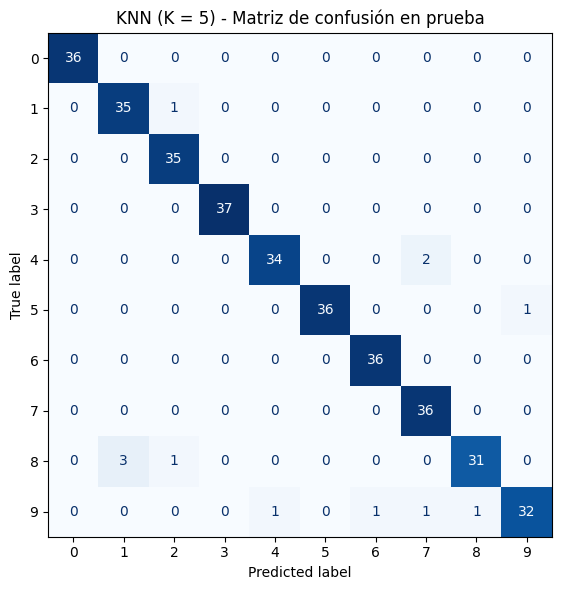

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_knn_test),
                        display_labels=digits.target_names).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"KNN (K = {mejor_K}) - Matriz de confusión en prueba")
fig.tight_layout()
plt.show()


## Clasificador RNN (vecinos dentro de un radio): selección de R por validación cruzada

El clasificador `RadiusNeighborsClassifier` vota entre los vecinos de entrenamiento
situados a una distancia **menor o igual al radio R** (en el espacio estandarizado).
A diferencia de KNN, **el número de vecinos considerados varía para cada muestra**, y
puede llegar a ser **cero** si ninguna muestra de entrenamiento cae dentro del radio.

Para manejar ese caso se usa `outlier_label=-1`: las muestras sin vecinos dentro del
radio se marcan como "sin clasificar" y se excluyen del cálculo de las métricas de
calidad, pero se contabilizan en una métrica adicional:

* **Cobertura**: porcentaje de muestras evaluadas que sí tuvieron al menos un vecino
  dentro del radio R.

Un radio muy pequeño puede dar métricas de calidad muy altas pero con **cobertura muy
baja** (el modelo "se abstiene" en la mayoría de los casos), mientras que un radio muy
grande cubre casi todas las muestras pero mezcla vecinos de otras clases, reduciendo la
calidad. El rango de radios se calibró observando la distancia típica entre vecinos
más cercanos en el espacio estandarizado (≈ 5 a 10).


In [9]:
rango_R = np.round(np.arange(3.0, 12.01, 0.5), 2)   # rango de radios a evaluar

metricas_rnn = {
    "Accuracy": np.zeros((len(rango_R), cv.get_n_splits())),
    "F1 macro": np.zeros((len(rango_R), cv.get_n_splits())),
    "Precisión macro": np.zeros((len(rango_R), cv.get_n_splits())),
    "Recall macro": np.zeros((len(rango_R), cv.get_n_splits())),
    "Cobertura": np.zeros((len(rango_R), cv.get_n_splits())),
}

for i, r in enumerate(rango_R):
    for j, (idx_tr, idx_val) in enumerate(cv.split(X_train, y_train)):
        X_tr, X_val = X_train[idx_tr], X_train[idx_val]
        y_tr, y_val = y_train[idx_tr], y_train[idx_val]

        escalador = StandardScaler().fit(X_tr)
        X_tr_s = escalador.transform(X_tr)
        X_val_s = escalador.transform(X_val)

        clf = RadiusNeighborsClassifier(radius=r, weights="distance", outlier_label=-1)
        clf.fit(X_tr_s, y_tr)
        pred = clf.predict(X_val_s)

        con_vecinos = pred != -1
        cobertura = con_vecinos.mean()
        metricas_rnn["Cobertura"][i, j] = cobertura

        if con_vecinos.sum() > 0:
            y_val_c = y_val[con_vecinos]
            pred_c = pred[con_vecinos]
            metricas_rnn["Accuracy"][i, j] = accuracy_score(y_val_c, pred_c)
            metricas_rnn["F1 macro"][i, j] = f1_score(y_val_c, pred_c, average="macro")
            metricas_rnn["Precisión macro"][i, j] = precision_score(y_val_c, pred_c, average="macro")
            metricas_rnn["Recall macro"][i, j] = recall_score(y_val_c, pred_c, average="macro")

promedio_rnn = {nombre: valores.mean(axis=1) for nombre, valores in metricas_rnn.items()}
desv_rnn = {nombre: valores.std(axis=1) for nombre, valores in metricas_rnn.items()}

print("Validación cruzada de RNN completada para R en "
      f"[{rango_R[0]}, {rango_R[-1]}].")


Validación cruzada de RNN completada para R en [3.0, 12.0].


### Figura: métricas de desempeño y cobertura en función de R

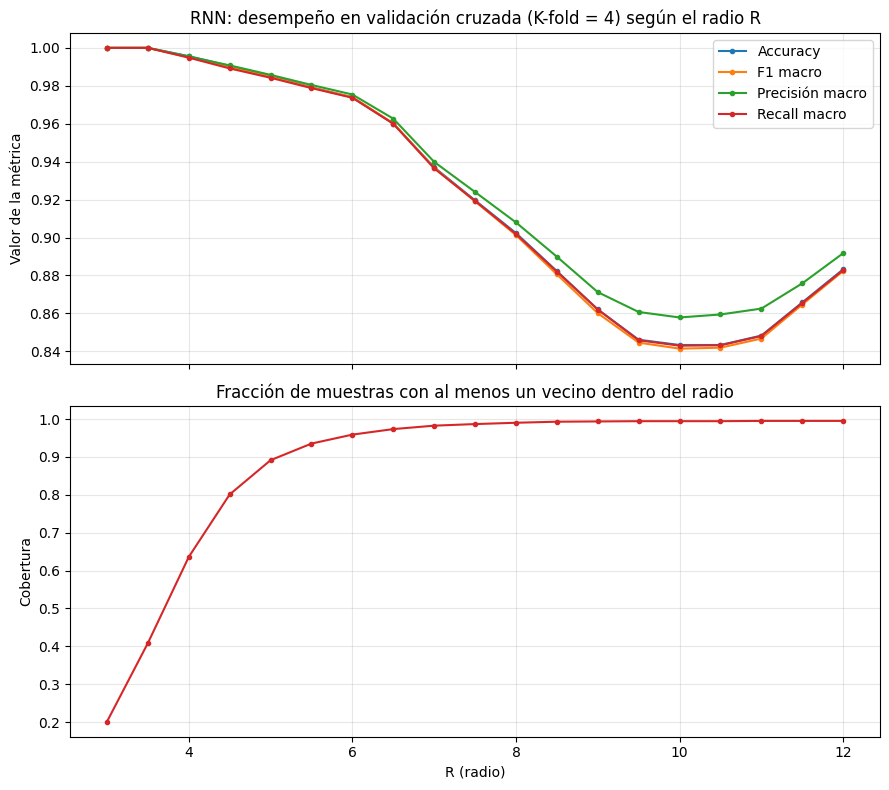

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

for nombre in ["Accuracy", "F1 macro", "Precisión macro", "Recall macro"]:
    ax1.plot(rango_R, promedio_rnn[nombre], marker="o", markersize=3, label=nombre)
ax1.set_ylabel("Valor de la métrica")
ax1.set_title("RNN: desempeño en validación cruzada (K-fold = 4) según el radio R")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(rango_R, promedio_rnn["Cobertura"], marker="o", markersize=3, color="tab:red")
ax2.set_xlabel("R (radio)")
ax2.set_ylabel("Cobertura")
ax2.set_title("Fracción de muestras con al menos un vecino dentro del radio")
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()


### Selección del mejor R

Elegir R por el mayor F1 macro a secas favorecería radios muy pequeños con cobertura
muy baja (el modelo casi no responde). Por eso se aplica un criterio más razonable:
entre los radios cuya **cobertura promedio sea de al menos 95 %**, se elige el que
tenga el mejor **F1 macro**. Así se garantiza que el modelo seleccionado clasifique la
gran mayoría de las muestras y no solo las más "fáciles".


In [11]:
cobertura_minima = 0.95
candidatos = np.where(promedio_rnn["Cobertura"] >= cobertura_minima)[0]

if len(candidatos) == 0:
    # Si ningún radio alcanza la cobertura mínima, se usa el de mayor cobertura disponible
    candidatos = np.array([int(np.argmax(promedio_rnn["Cobertura"]))])

mejor_indice_R = candidatos[np.argmax(promedio_rnn["F1 macro"][candidatos])]
mejor_R = rango_R[mejor_indice_R]

print(f"Mejor R encontrado (cobertura >= {cobertura_minima:.0%}): {mejor_R}")
print(f"  Accuracy (CV):        {promedio_rnn['Accuracy'][mejor_indice_R]:.4f}")
print(f"  F1 macro (CV):        {promedio_rnn['F1 macro'][mejor_indice_R]:.4f}")
print(f"  Precisión macro (CV): {promedio_rnn['Precisión macro'][mejor_indice_R]:.4f}")
print(f"  Recall macro (CV):    {promedio_rnn['Recall macro'][mejor_indice_R]:.4f}")
print(f"  Cobertura (CV):       {promedio_rnn['Cobertura'][mejor_indice_R]:.4f}")


Mejor R encontrado (cobertura >= 95%): 6.0
  Accuracy (CV):        0.9739
  F1 macro (CV):        0.9740
  Precisión macro (CV): 0.9754
  Recall macro (CV):    0.9737
  Cobertura (CV):       0.9589


### Evaluación final de RNN sobre el conjunto de prueba

Igual que con KNN, el modelo definitivo se entrena con **todo** el conjunto de
entrenamiento usando el **R** seleccionado, y se evalúa **una sola vez** sobre el
conjunto de prueba. Las muestras de prueba sin vecinos dentro del radio se reportan
como cobertura, no se fuerzan a una clase arbitraria.


In [12]:
escalador_rnn_final = StandardScaler().fit(X_train)
X_train_s2 = escalador_rnn_final.transform(X_train)
X_test_s2 = escalador_rnn_final.transform(X_test)

clf_rnn_final = RadiusNeighborsClassifier(radius=mejor_R, weights="distance", outlier_label=-1)
clf_rnn_final.fit(X_train_s2, y_train)
pred_rnn_test = clf_rnn_final.predict(X_test_s2)

con_vecinos_test = pred_rnn_test != -1
cobertura_test = con_vecinos_test.mean()

print(f"Resultados de RNN (R = {mejor_R}) sobre el conjunto de prueba:")
print(f"Cobertura en prueba: {cobertura_test:.4f} "
      f"({con_vecinos_test.sum()} de {len(y_test)} muestras clasificadas)\n")
print(classification_report(y_test[con_vecinos_test], pred_rnn_test[con_vecinos_test], digits=3))


Resultados de RNN (R = 6.0) sobre el conjunto de prueba:
Cobertura en prueba: 0.9667 (348 de 360 muestras clasificadas)

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        35
           1      0.833     1.000     0.909        35
           2      1.000     1.000     1.000        35
           3      0.974     1.000     0.987        37
           4      0.969     1.000     0.984        31
           5      1.000     0.973     0.986        37
           6      1.000     0.972     0.986        36
           7      1.000     1.000     1.000        35
           8      0.964     0.794     0.871        34
           9      0.969     0.939     0.954        33

    accuracy                          0.968       348
   macro avg      0.971     0.968     0.968       348
weighted avg      0.971     0.968     0.968       348



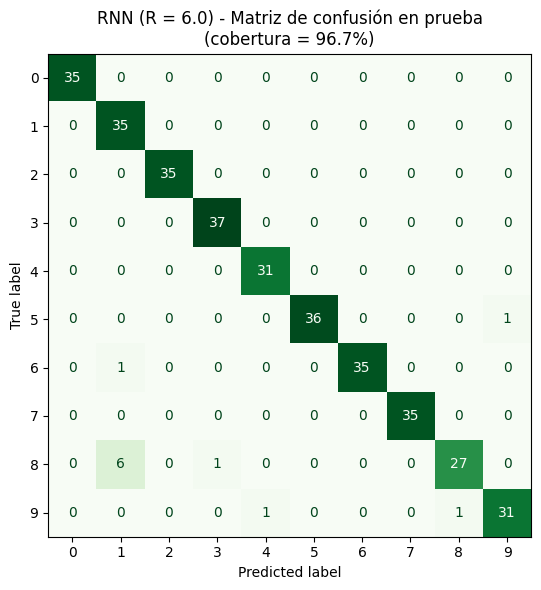

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test[con_vecinos_test], pred_rnn_test[con_vecinos_test]),
                        display_labels=digits.target_names).plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title(f"RNN (R = {mejor_R}) - Matriz de confusión en prueba\n"
             f"(cobertura = {cobertura_test:.1%})")
fig.tight_layout()
plt.show()


## Comparación final y conclusiones

La siguiente tabla resume el desempeño de ambos clasificadores, ya calibrados por
validación cruzada de 4 particiones y evaluados sobre el mismo conjunto de prueba
(20 % del total, no usado en ningún momento del ajuste de hiperparámetros).


In [14]:
from sklearn.metrics import accuracy_score as _acc, f1_score as _f1

resumen = {
    "Clasificador": ["KNN", "RNN"],
    "Hiperparámetro": [f"K = {mejor_K}", f"R = {mejor_R}"],
    "Accuracy (prueba)": [
        _acc(y_test, pred_knn_test),
        _acc(y_test[con_vecinos_test], pred_rnn_test[con_vecinos_test]),
    ],
    "F1 macro (prueba)": [
        _f1(y_test, pred_knn_test, average="macro"),
        _f1(y_test[con_vecinos_test], pred_rnn_test[con_vecinos_test], average="macro"),
    ],
    "Cobertura (prueba)": [1.0, cobertura_test],
}

ancho = max(len(c) for c in resumen["Clasificador"]) + 2
print(f"{'Clasificador':<14}{'Hiperparámetro':<16}{'Accuracy':<12}{'F1 macro':<12}{'Cobertura':<10}")
for i in range(2):
    print(f"{resumen['Clasificador'][i]:<14}{resumen['Hiperparámetro'][i]:<16}"
          f"{resumen['Accuracy (prueba)'][i]:<12.4f}{resumen['F1 macro (prueba)'][i]:<12.4f}"
          f"{resumen['Cobertura (prueba)'][i]:<10.4f}")


Clasificador  Hiperparámetro  Accuracy    F1 macro    Cobertura 
KNN           K = 5           0.9667      0.9661      1.0000    
RNN           R = 6.0         0.9684      0.9677      0.9667    


**Observaciones:**

* **KNN** clasifica siempre el 100 % de las muestras (cobertura = 1), ya que siempre
  toma los K vecinos más cercanos sin importar la distancia a la que se encuentren.
  En este conjunto de datos alcanza un desempeño muy alto con valores pequeños de K
  (alrededor de K = 4-6), típico de `digits`, donde las clases están bien separadas en
  el espacio de 64 características.
* **RNN** exige fijar una noción absoluta de "cercanía" (el radio) en vez de un número
  de vecinos, lo que introduce el concepto de **cobertura**: siempre existe una
  posibilidad de que una muestra de prueba quede sin vecinos dentro del radio elegido
  y no pueda clasificarse. El criterio usado aquí (mejor F1 macro con cobertura ≥ 95 %)
  intenta balancear calidad y capacidad de respuesta del modelo.
* En un espacio de alta dimensión (64 características) y con dígitos relativamente bien
  separados, ambos métodos logran un desempeño competitivo, pero **KNN resulta más
  robusto y sencillo de operar** porque no depende de una escala de distancia fija:
  se adapta automáticamente a la densidad local de cada muestra.
* En ambos casos es fundamental **estandarizar las características** antes de calcular
  distancias, y **separar el conjunto de prueba antes de cualquier ajuste** (incluido el
  del escalador) para no sesgar la evaluación final.
